In [1]:
import os
import sys

synsin_path = os.path.expanduser("~/Assign_5/synsin")
os.chdir(synsin_path)

if synsin_path not in sys.path:
    sys.path.insert(0, synsin_path)

print("Current working directory:", os.getcwd())
print("SynSin path added to sys.path:", sys.path[0])

Current working directory: /home/mad03633/Assign_5/synsin
SynSin path added to sys.path: /home/mad03633/Assign_5/synsin


In [2]:
import torch


print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.1.2+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
import torch.nn as nn
from models.networks.sync_batchnorm import convert_model
from models.base_model import BaseModel
from options.options import get_model


# Load the Pretrained SynSin Model for RealEstate10K
MODEL_PATH = "./modelcheckpoints/realestate/zbufferpts.pth"

checkpoint = torch.load(MODEL_PATH, map_location="cpu")
opts = checkpoint["opts"]
opts.render_ids = [1]

model = get_model(opts)

if torch.cuda.is_available():
    torch_devices = [int(gpu_id.strip()) for gpu_id in opts.gpu_ids.split(",")]
    if "sync" in opts.norm_G:
        model = convert_model(model)
    model = nn.DataParallel(model, torch_devices[0:1]).cuda()

model_to_test = BaseModel(model, opts)
model_to_test.load_state_dict(checkpoint["state_dict"])
model_to_test.eval()

print("Model loaded successfully")
print("Checkpoint:", MODEL_PATH)

Loading model %s ... 
RESNET encoder
RESNET decoder
['1.0_l1', '10.0_content']


/home/mad03633/Assign_5/graphics/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mad03633/Assign_5/graphics/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model loaded successfully
Checkpoint: ./modelcheckpoints/realestate/zbufferpts.pth


In [4]:
import torchvision.transforms as transforms


# Define image preprocessing and normalization pipeline
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [5]:
# Function to load an image and convert it to a tensor
def load_image_tensor(image_path: str):
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img)
    return img, img_tensor

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


# Function for novel view synthesis with SynSin
def synthesize_view(
    image_path: str,
    theta: float = -0.15,
    phi: float = -0.10,
    tx: float = 0.0,
    ty: float = 0.0,
    tz: float = 0.10,
    show: bool = True,
    save_prefix: str = None,
):
    pil_img, im = load_image_tensor(image_path)

    RT = torch.eye(4).unsqueeze(0)
    rot_matrix = R.from_rotvec([phi, theta, 0]).as_matrix()
    RT[0, 0:3, 0:3] = torch.tensor(rot_matrix, dtype=torch.float32)
    RT[0, 0:3, 3] = torch.tensor([tx, ty, tz], dtype=torch.float32)

    batch = {
        "images": [im.unsqueeze(0)],
        "cameras": [{
            "K": torch.eye(4).unsqueeze(0),
            "Kinv": torch.eye(4).unsqueeze(0)
        }]
    }

    with torch.no_grad():
        if torch.cuda.is_available():
            pred_imgs = model_to_test.model.module.forward_angle(batch, [RT])
            depth = nn.Sigmoid()(model_to_test.model.module.pts_regressor(batch["images"][0].cuda()))
        else:
            pred_imgs = model_to_test.model.module.forward_angle(batch, [RT])
            depth = nn.Sigmoid()(model_to_test.model.module.pts_regressor(batch["images"][0]))

    input_np = (im.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
    pred_np = (pred_imgs[0].squeeze().detach().cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
    depth_np = depth.squeeze().detach().cpu().numpy()

    if show:
        fig, axis = plt.subplots(1, 3, figsize=(15, 5))

        axis[0].imshow(input_np)
        axis[0].set_title("Input image")
        axis[0].axis("off")

        axis[1].imshow(pred_np)
        axis[1].set_title(f"Generated view\nθ={theta}, φ={phi}, tx={tx}, ty={ty}, tz={tz}")
        axis[1].axis("off")

        axis[2].imshow(np.clip(depth_np, 0, 0.04), cmap="viridis")
        axis[2].set_title("Predicted depth")
        axis[2].axis("off")

        plt.tight_layout()
        plt.show()

    if save_prefix is not None:
        Image.fromarray((input_np * 255).astype(np.uint8)).save(f"{save_prefix}_input.png")
        Image.fromarray((pred_np * 255).astype(np.uint8)).save(f"{save_prefix}_generated.png")

        depth_vis = np.clip(depth_np, 0, 0.04)
        depth_vis = depth_vis / (depth_vis.max() + 1e-8)
        depth_vis = (depth_vis * 255).astype(np.uint8)
        Image.fromarray(depth_vis).save(f"{save_prefix}_depth.png")

    return {
        "input": input_np,
        "generated": pred_np,
        "depth": depth_np,
        "params": {
            "theta": theta,
            "phi": phi,
            "tx": tx,
            "ty": ty,
            "tz": tz
        }
    }

In [12]:
import glob


# Collect and display all test images
image_paths = sorted(
    glob.glob(os.path.expanduser("~/Assign_5/my_images/*.jpg")) +
    glob.glob(os.path.expanduser("~/Assign_5/my_images/*.jpeg")) +
    glob.glob(os.path.expanduser("~/Assign_5/my_images/*.png"))
)

print("Number of test images found:", len(image_paths))
for p in image_paths:
    print(p)

Number of test images found: 3
/home/mad03633/Assign_5/my_images/bishop_.jpg
/home/mad03633/Assign_5/my_images/books.jpg
/home/mad03633/Assign_5/my_images/terence.jpg


Max dist:  tensor(0.0010, device='cuda:0') 0.0009765625
Max dist:  tensor(1.0000, device='cuda:0')


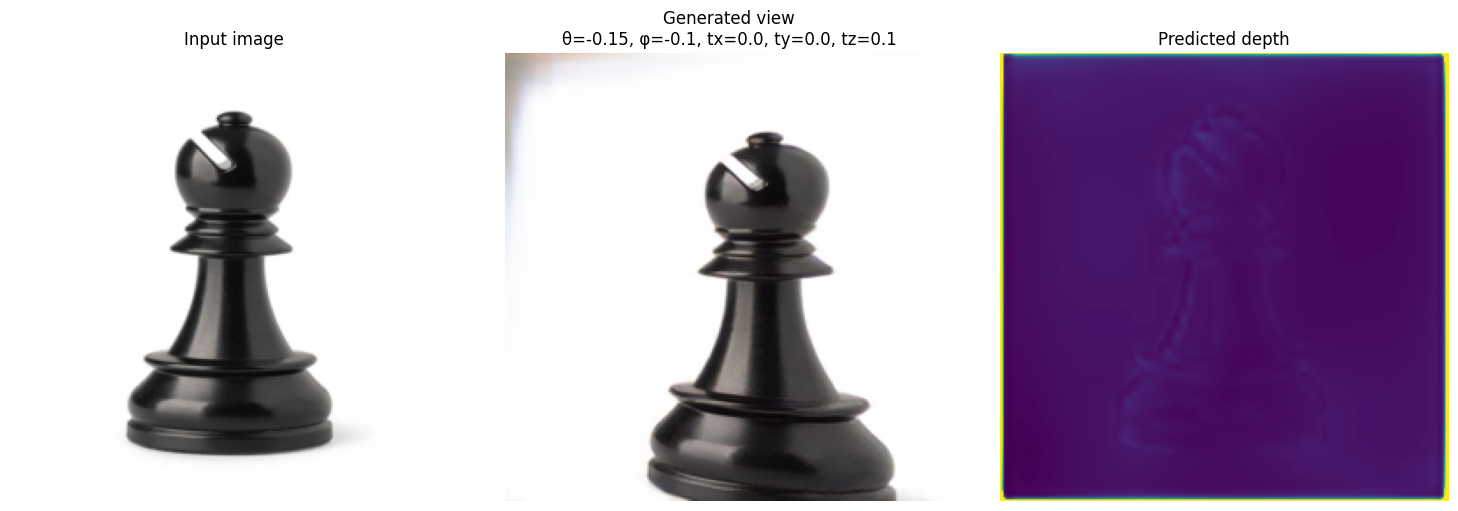

In [15]:
from scipy.spatial.transform import Rotation as R


# Run a single test inference on one image
os.environ["DEBUG"] = "0"

test_image = image_paths[0]

result = synthesize_view(
    image_path=test_image,
    theta=-0.15,
    phi=-0.10,
    tx=0.0,
    ty=0.0,
    tz=0.10,
    show=True,
    save_prefix=os.path.expanduser("~/Assign_5/outputs/test_image")
)


=== Variant 1 ===
Max dist:  tensor(0.0010, device='cuda:0') 0.0009765625
Max dist:  tensor(1.0000, device='cuda:0')


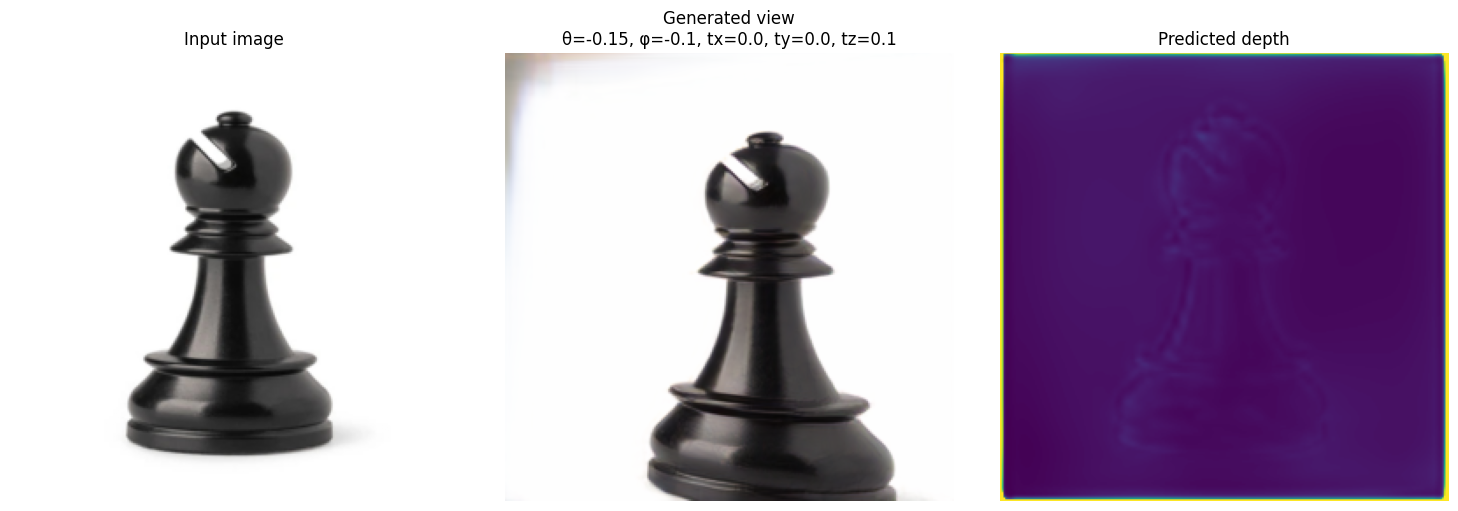


=== Variant 2 ===
Max dist:  tensor(0.0010, device='cuda:0') 0.0009765625
Max dist:  tensor(1.0000, device='cuda:0')


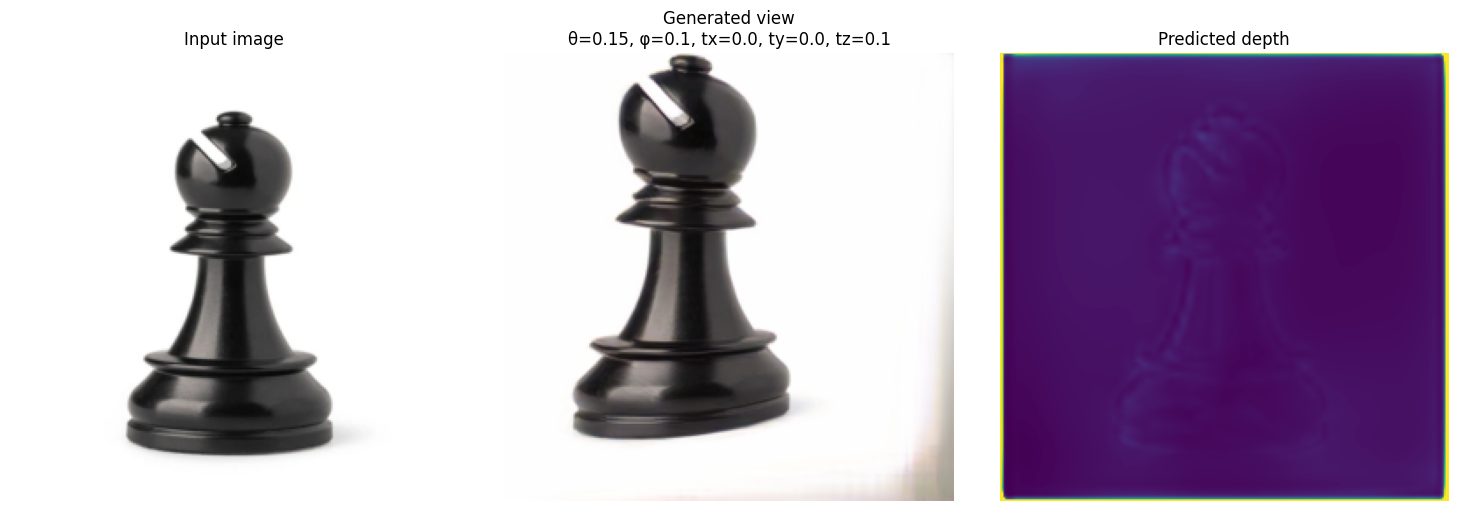


=== Variant 3 ===
Max dist:  tensor(0.0010, device='cuda:0') 0.0009765625
Max dist:  tensor(1.0000, device='cuda:0')


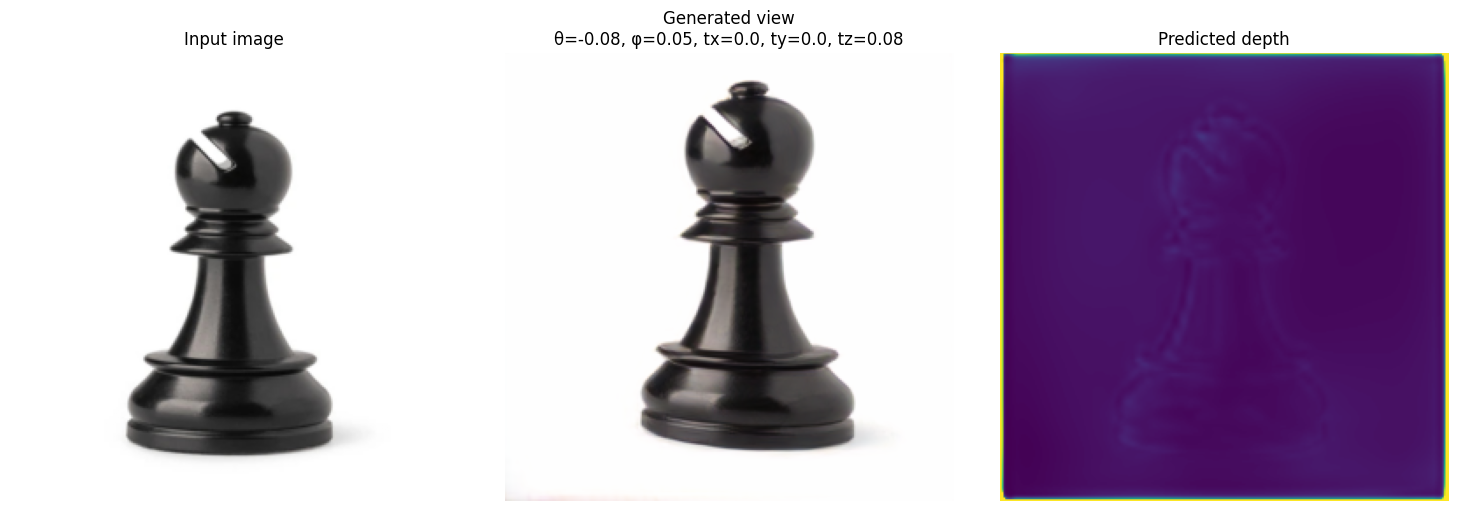

In [17]:
from pathlib import Path
import os


test_image = image_paths[0]
output_dir = Path(os.path.expanduser("~/Assign_5/outputs"))
output_dir.mkdir(parents=True, exist_ok=True)

# Apply several small view transformations to one image
param_grid = [
    {"theta": -0.15, "phi": -0.10, "tx": 0.0, "ty": 0.0, "tz": 0.10},
    {"theta":  0.15, "phi":  0.10, "tx": 0.0, "ty": 0.0, "tz": 0.10},
    {"theta": -0.08, "phi":  0.05, "tx": 0.0, "ty": 0.0, "tz": 0.08},
]

for i, params in enumerate(param_grid, start=1):
    print(f"\n=== Variant {i} ===")
    synthesize_view(
        image_path=test_image,
        save_prefix=str(output_dir / f"{Path(test_image).stem}_variant{i}"),
        **params
    )


Processing: /home/mad03633/Assign_5/my_images/bishop_.jpg
Parameters: {'theta': -0.08, 'phi': 0.05, 'tx': 0.0, 'ty': 0.0, 'tz': 0.08}
Max dist:  tensor(0.0010, device='cuda:0') 0.0009765625
Max dist:  tensor(1.0000, device='cuda:0')


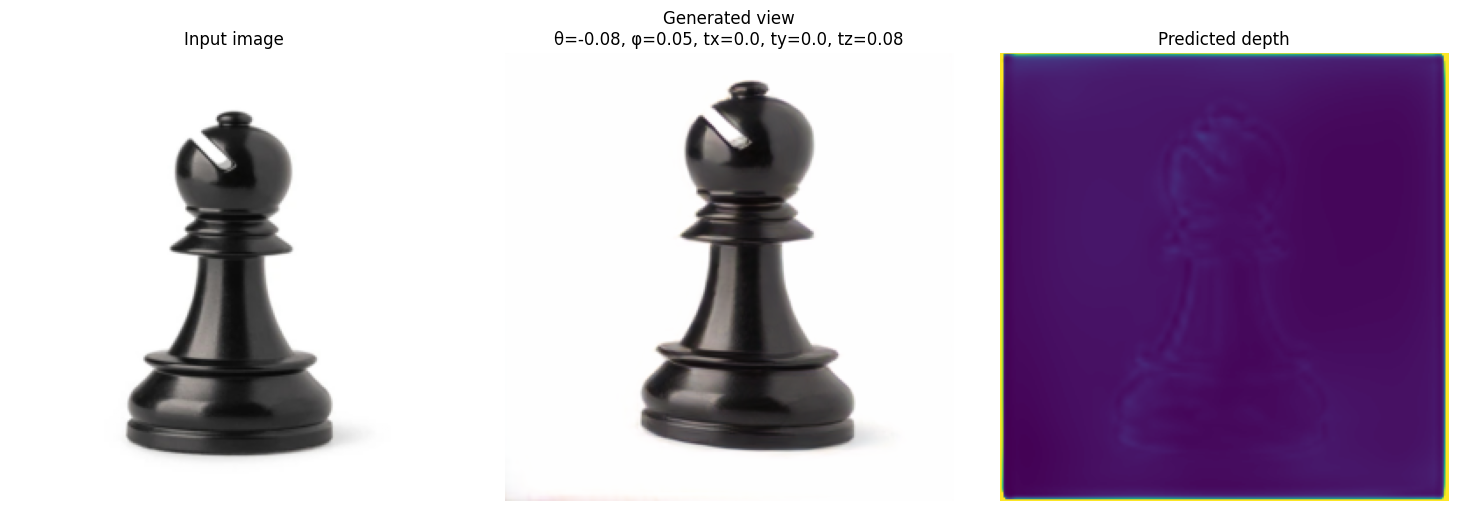


Processing: /home/mad03633/Assign_5/my_images/books.jpg
Parameters: {'theta': -0.08, 'phi': -0.05, 'tx': 0.0, 'ty': 0.0, 'tz': 0.08}
Max dist:  tensor(0.0010, device='cuda:0') 0.0009765625
Max dist:  tensor(1.0000, device='cuda:0')


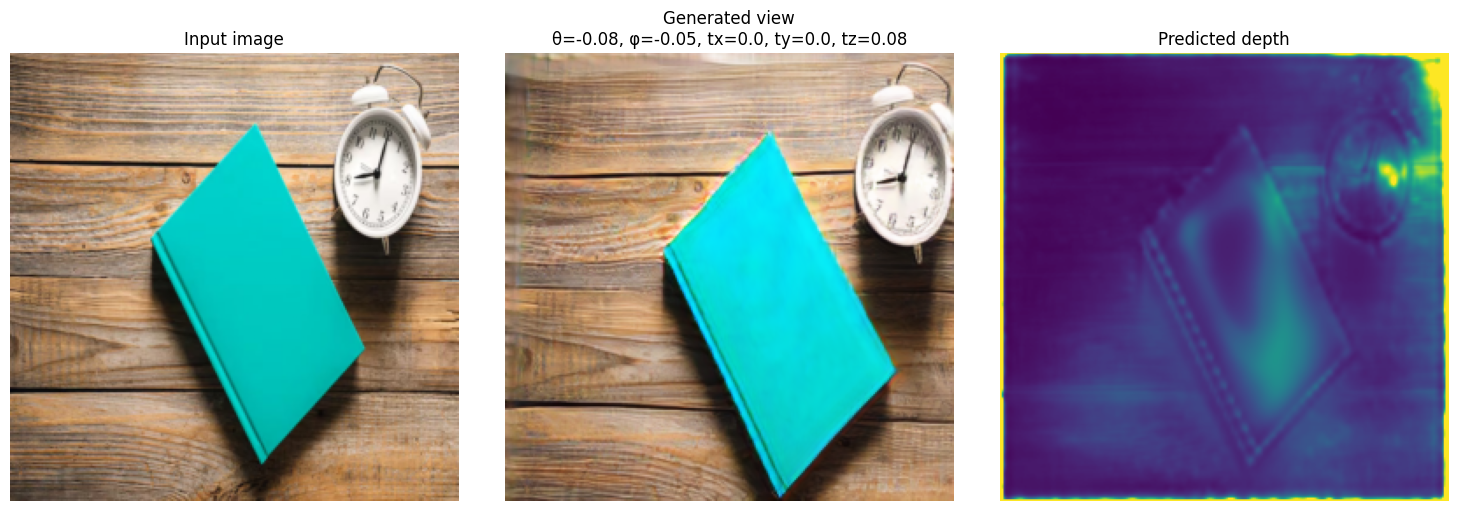


Processing: /home/mad03633/Assign_5/my_images/terence.jpg
Parameters: {'theta': -0.05, 'phi': 0.03, 'tx': 0.0, 'ty': 0.0, 'tz': 0.06}
Max dist:  tensor(0.0010, device='cuda:0') 0.0009765625
Max dist:  tensor(1.0000, device='cuda:0')


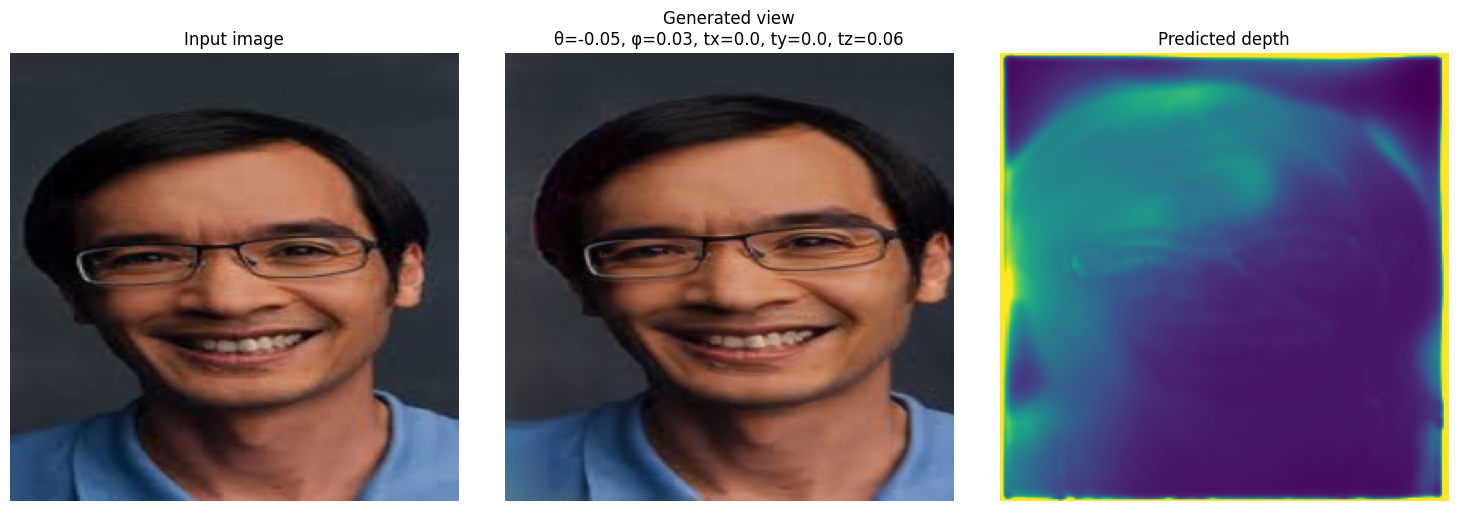

In [18]:
# Run inference on all test images with chosen parameters
def get_best_params(image_path):
    stem = Path(image_path).stem.lower()

    if "bishop" in stem:
        return {"theta": -0.08, "phi": 0.05, "tx": 0.0, "ty": 0.0, "tz": 0.08}
    elif "book" in stem:
        return {"theta": -0.08, "phi": -0.05, "tx": 0.0, "ty": 0.0, "tz": 0.08}
    elif "terence" in stem:
        return {"theta": -0.05, "phi": 0.03, "tx": 0.0, "ty": 0.0, "tz": 0.06}
    else:
        return {"theta": -0.08, "phi": 0.05, "tx": 0.0, "ty": 0.0, "tz": 0.08}

all_runs = []

for img_path in image_paths:
    params = get_best_params(img_path)
    stem = Path(img_path).stem

    print(f"\nProcessing: {img_path}")
    print("Parameters:", params)

    synthesize_view(
        image_path=img_path,
        show=True,
        save_prefix=str(output_dir / stem),
        **params
    )

    all_runs.append({
        "image": img_path,
        "image_name": stem,
        **params
    })

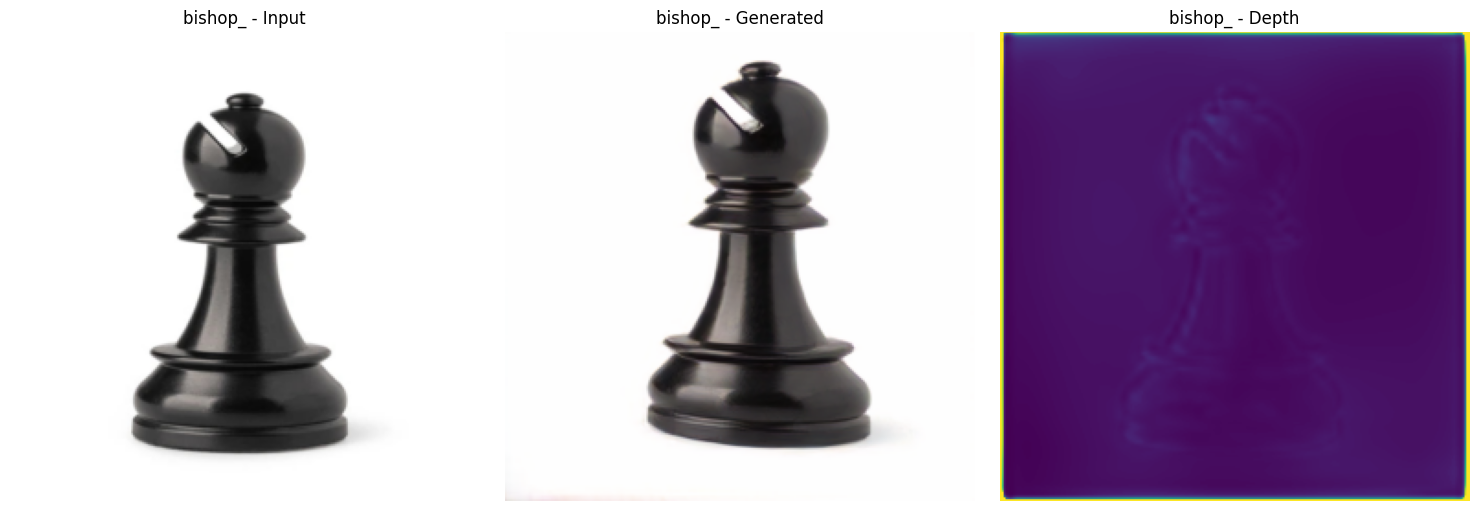

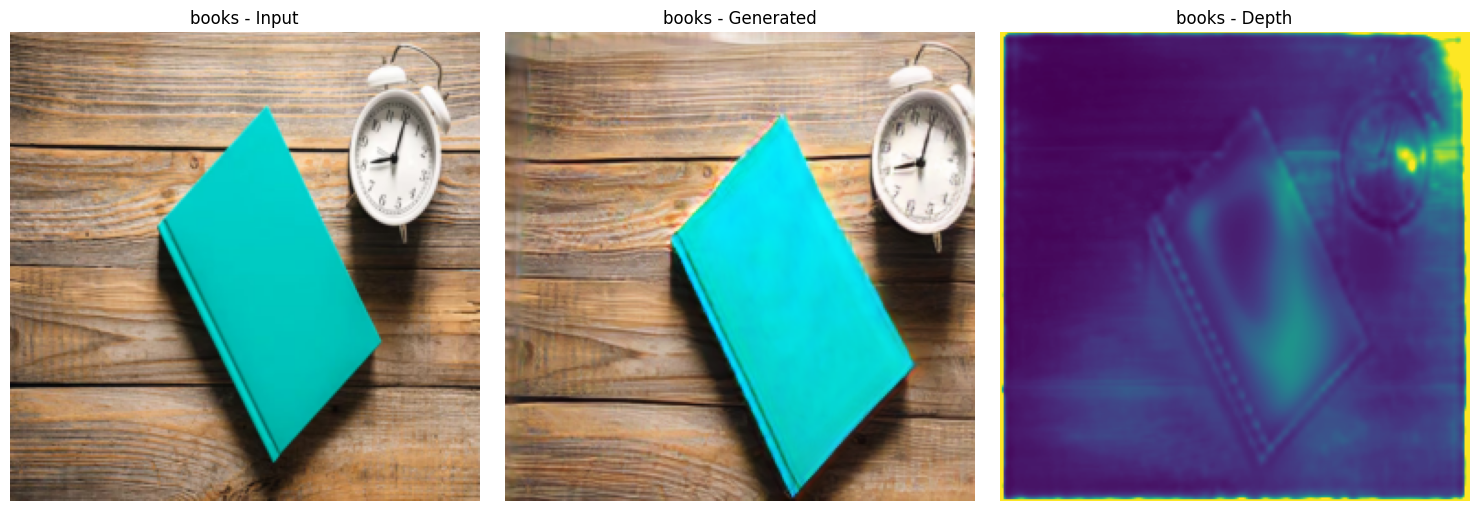

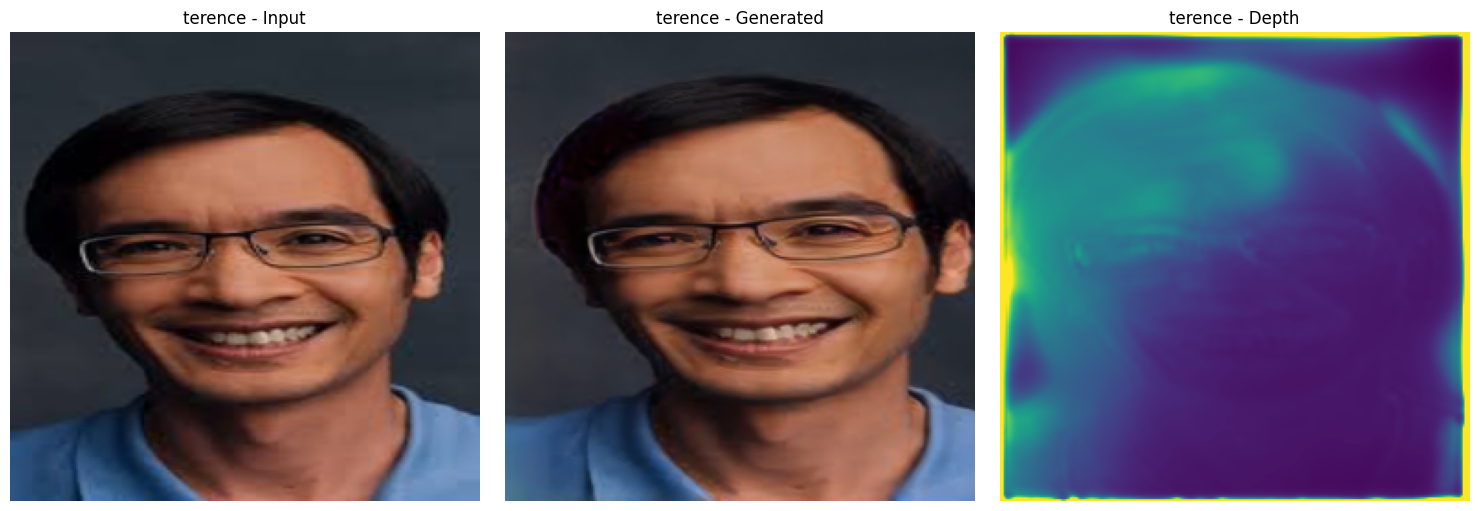

In [19]:
# Display saved output triplets
for run in all_runs:
    stem = run["image_name"]

    input_path = output_dir / f"{stem}_input.png"
    gen_path = output_dir / f"{stem}_generated.png"
    depth_path = output_dir / f"{stem}_depth.png"

    if input_path.exists() and gen_path.exists() and depth_path.exists():
        input_img = Image.open(input_path)
        gen_img = Image.open(gen_path)
        depth_img = Image.open(depth_path)

        fig, ax = plt.subplots(1, 3, figsize=(15, 5))

        ax[0].imshow(input_img)
        ax[0].set_title(f"{stem} - Input")
        ax[0].axis("off")

        ax[1].imshow(gen_img)
        ax[1].set_title(f"{stem} - Generated")
        ax[1].axis("off")

        ax[2].imshow(depth_img, cmap="viridis")
        ax[2].set_title(f"{stem} - Depth")
        ax[2].axis("off")

        plt.tight_layout()
        plt.show()

In [20]:
import pandas as pd

report_rows = []

for run in all_runs:
    report_rows.append({
        "image_name": run["image_name"],
        "image_path": run["image"],
        "theta": run["theta"],
        "phi": run["phi"],
        "tx": run["tx"],
        "ty": run["ty"],
        "tz": run["tz"],
        "worked_well": "",
        "worked_poorly": "",
        "artifacts": "",
        "hypothesis_why": "",
        "related_to_train_domain_shift": ""
    })

df_report = pd.DataFrame(report_rows)
df_report

,image_name,image_path,theta,phi,tx,ty,tz,worked_well,worked_poorly,artifacts,hypothesis_why,related_to_train_domain_shift
0,bishop_,/home/mad03633/Assign_5/my_images/bishop_.jpg,-0.08,0.05,0.0,0.0,0.08,,,,,
1,books,/home/mad03633/Assign_5/my_images/books.jpg,-0.08,-0.05,0.0,0.0,0.08,,,,,
2,terence,/home/mad03633/Assign_5/my_images/terence.jpg,-0.05,0.03,0.0,0.0,0.06,,,,,
